In [2]:
!pip install duckdb pandas pyarrow missingno -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

df = pd.read_parquet("/content/drive/MyDrive/DT_Engg_Project/team_4.parquet")
print(f"Shape: {df.shape}")
print(f"Total cells: {df.shape[0] * df.shape[1]:,}")

Shape: (5831431, 22)
Total cells: 128,291,482


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
missing = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_pct': (df.isna().sum() / len(df) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing = missing[missing['missing_count'] > 0]
print("=== BEFORE CLEANING — Missing Values ===")
print(missing.to_string())

total_missing = df.isna().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"\nOverall data quality: {100 - (total_missing/total_cells*100):.1f}% complete")
print(f"Total missing cells: {total_missing:,} out of {total_cells:,}")

=== BEFORE CLEANING — Missing Values ===
            missing_count  missing_pct
vws_m_s           5831431       100.00
ws_m_s            2540853        43.57
sr_w_mt2          2213776        37.96
at_c              1990984        34.14
bp_mmhg           1950992        33.46
rf_mm             1941815        33.30
wd_deg            1529016        26.22
rh_percent        1403566        24.07

Overall data quality: 84.9% complete
Total missing cells: 19,402,433 out of 128,291,482


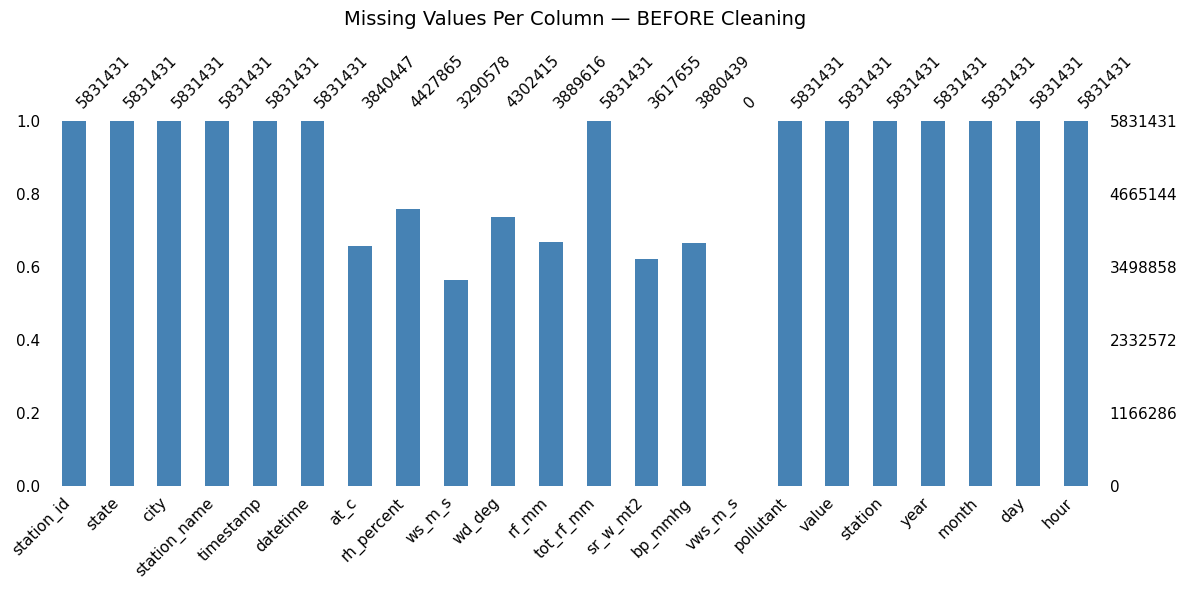

Saved: missing_before.png


In [7]:
plt.figure(figsize=(12, 6))
msno.bar(df, figsize=(12, 6), fontsize=11, color='steelblue')
plt.title("Missing Values Per Column — BEFORE Cleaning", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("missing_before.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: missing_before.png")

In [8]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes:,}")
print(f"Unique station IDs: {df['station_id'].nunique()}")
print(f"Unique pollutants: {df['pollutant'].nunique()} → {sorted(df['pollutant'].unique())}")
print(f"Datetime range: {df['datetime'].min()} → {df['datetime'].max()}")
print(f"\nValue column stats:")
print(df['value'].describe().round(2))

Duplicate rows: 0
Unique station IDs: 10
Unique pollutants: 13 → ['benzene', 'co', 'eth_benzene', 'mp_xylene', 'nh3', 'no', 'no2', 'ozone', 'pm10', 'pm25', 'so2', 'toluene', 'xylene']
Datetime range: 2024-01-01 00:00:00+00:00 → 2025-12-31 23:45:00+00:00

Value column stats:
count    5831431.00
mean          51.48
std           90.54
min            0.00
25%            2.82
50%           19.00
75%           53.59
max         1000.00
Name: value, dtype: float64


In [9]:
negatives = (df['value'] < 0).sum()
print(f"Negative pollution readings: {negatives:,}")
print(f"That's {negatives/len(df)*100:.2f}% of all readings")

print("\nNegative values by pollutant:")
neg_by_pollutant = df[df['value'] < 0].groupby('pollutant').size()
print(neg_by_pollutant.to_string())

Negative pollution readings: 0
That's 0.00% of all readings

Negative values by pollutant:
Series([], )


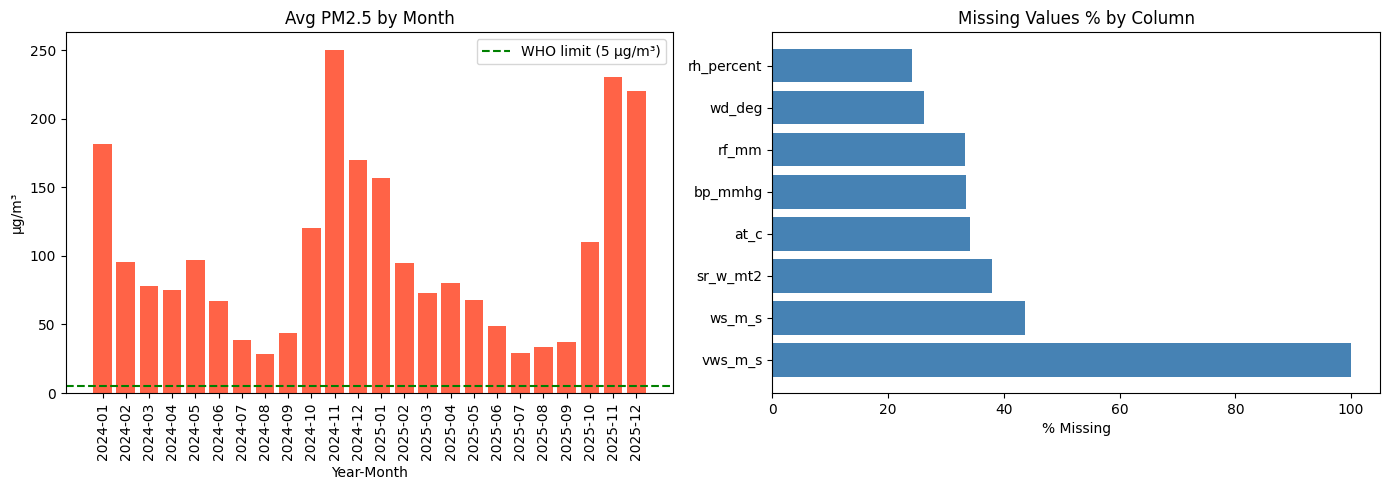

Saved: eda_overview.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PM2.5 monthly average
pm25 = df[df['pollutant'] == 'pm25'].groupby(['year', 'month'])['value'].mean().reset_index()
pm25['period'] = pm25['year'].astype(str) + '-' + pm25['month'].astype(str).str.zfill(2)
axes[0].bar(pm25['period'], pm25['value'], color='tomato')
axes[0].set_title('Avg PM2.5 by Month')
axes[0].set_xlabel('Year-Month')
axes[0].set_ylabel('µg/m³')
axes[0].tick_params(axis='x', rotation=90)
axes[0].axhline(y=5, color='green', linestyle='--', label='WHO limit (5 µg/m³)')
axes[0].legend()

# Missing values per column
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
axes[1].barh(missing_pct.index, missing_pct.values, color='steelblue')
axes[1].set_title('Missing Values % by Column')
axes[1].set_xlabel('% Missing')

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_overview.png")

In [11]:
df_clean = df.copy()
rows_before = len(df_clean)

# 1. Drop 100% null column
df_clean = df_clean.drop(columns=['vws_m_s'])
print(f"✓ Dropped 'vws_m_s' (100% null)")

# 2. Drop duplicate timestamp column (VARCHAR version)
df_clean = df_clean.drop(columns=['timestamp'])
print(f"✓ Dropped 'timestamp' (duplicate of datetime, stored as text)")

# 3. Drop duplicate station column
df_clean = df_clean.drop(columns=['station'])
print(f"✓ Dropped 'station' (duplicate of station_id)")

# 4. Remove negative pollution values (physically impossible)
neg_mask = df_clean['value'] < 0
df_clean = df_clean[~neg_mask]
print(f"✓ Removed {neg_mask.sum():,} negative pollution readings")

# 5. Remove duplicate rows
dupes_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()
print(f"✓ Removed {dupes_before:,} duplicate rows")

# 6. Fill missing weather values with station-month median
# (better than overall mean — respects seasonal variation)
weather_cols = ['at_c', 'rh_percent', 'ws_m_s', 'wd_deg', 'rf_mm', 'tot_rf_mm', 'sr_w_mt2', 'bp_mmhg']
for col in weather_cols:
    if col in df_clean.columns:
        before = df_clean[col].isna().sum()
        df_clean[col] = df_clean.groupby(['station_id', 'month'])[col].transform(
            lambda x: x.fillna(x.median())
        )
        after = df_clean[col].isna().sum()
        print(f"✓ Filled {before - after:,} missing values in '{col}' with station-month median")

rows_after = len(df_clean)
print(f"\nRows: {rows_before:,} → {rows_after:,} (removed {rows_before - rows_after:,})")
print(f"Columns: {df.shape[1]} → {df_clean.shape[1]} (dropped {df.shape[1] - df_clean.shape[1]})")

✓ Dropped 'vws_m_s' (100% null)
✓ Dropped 'timestamp' (duplicate of datetime, stored as text)
✓ Dropped 'station' (duplicate of station_id)
✓ Removed 0 negative pollution readings
✓ Removed 0 duplicate rows
✓ Filled 108,607 missing values in 'at_c' with station-month median
✓ Filled 200,877 missing values in 'rh_percent' with station-month median
✓ Filled 583,563 missing values in 'ws_m_s' with station-month median
✓ Filled 298,757 missing values in 'wd_deg' with station-month median
✓ Filled 144,304 missing values in 'rf_mm' with station-month median
✓ Filled 0 missing values in 'tot_rf_mm' with station-month median
✓ Filled 396,671 missing values in 'sr_w_mt2' with station-month median
✓ Filled 127,774 missing values in 'bp_mmhg' with station-month median

Rows: 5,831,431 → 5,831,431 (removed 0)
Columns: 22 → 19 (dropped 3)


In [12]:
missing_after = pd.DataFrame({
    'missing_count': df_clean.isna().sum(),
    'missing_pct': (df_clean.isna().sum() / len(df_clean) * 100).round(2)
}).sort_values('missing_pct', ascending=False)

missing_after = missing_after[missing_after['missing_count'] > 0]

total_missing_after = df_clean.isna().sum().sum()
total_cells_after = df_clean.shape[0] * df_clean.shape[1]
quality_after = 100 - (total_missing_after / total_cells_after * 100)

total_missing_before = df.isna().sum().sum()
total_cells_before = df.shape[0] * df.shape[1]
quality_before = 100 - (total_missing_before / total_cells_before * 100)

print("=" * 50)
print("   BEFORE vs AFTER CLEANING")
print("=" * 50)
print(f"{'Metric':<30} {'Before':>10} {'After':>10}")
print("-" * 50)
print(f"{'Rows':<30} {rows_before:>10,} {rows_after:>10,}")
print(f"{'Columns':<30} {df.shape[1]:>10} {df_clean.shape[1]:>10}")
print(f"{'Missing cells':<30} {total_missing_before:>10,} {total_missing_after:>10,}")
print(f"{'Data quality %':<30} {quality_before:>10.1f} {quality_after:>10.1f}")
print("=" * 50)
print(f"\n→ Data quality improved by {quality_after - quality_before:.1f} percentage points")

   BEFORE vs AFTER CLEANING
Metric                             Before      After
--------------------------------------------------
Rows                            5,831,431  5,831,431
Columns                                22         19
Missing cells                  19,402,433 11,710,449
Data quality %                       84.9       89.4

→ Data quality improved by 4.6 percentage points


In [13]:
df_clean.to_parquet("team_4_clean.parquet", index=False)
print(f"✓ Saved clean dataset: team_4_clean.parquet")
print(f"  Shape: {df_clean.shape}")

# Download it
from google.colab import files
files.download("team_4_clean.parquet")
files.download("missing_before.png")
files.download("eda_overview.png")

✓ Saved clean dataset: team_4_clean.parquet
  Shape: (5831431, 19)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

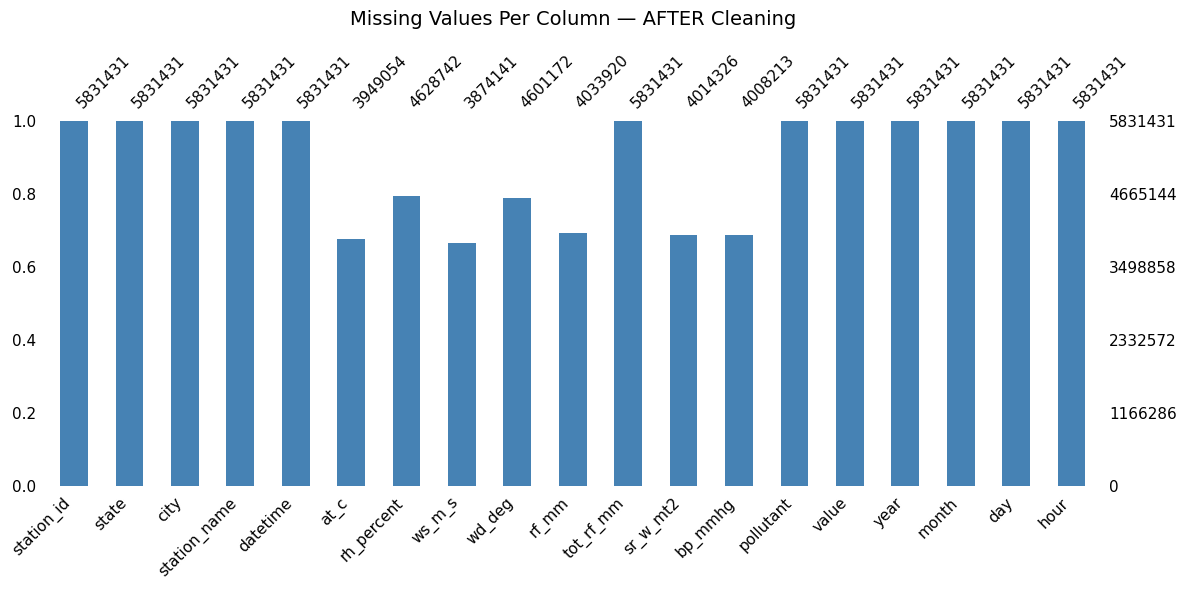

CLEANING SUMMARY
Columns removed  : 3 (vws_m_s, timestamp, station)
Values imputed   : 1,860,553 weather readings filled with station-month median
Rows removed     : 0 (no duplicates or negatives found)
Quality before   : 84.9%
Quality after    : 89.4%
Improvement      : +4.6 percentage points
Remaining nulls  : weather columns with no station readings for entire months


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# After cleaning — missing value visual
plt.figure(figsize=(12, 6))
msno.bar(df_clean, figsize=(12, 6), fontsize=11, color='steelblue')
plt.title("Missing Values Per Column — AFTER Cleaning", fontsize=14, pad=20)
plt.tight_layout()
plt.savefig("missing_after.png", dpi=150, bbox_inches='tight')
plt.show()

# Side by side summary
print("CLEANING SUMMARY")
print(f"Columns removed  : 3 (vws_m_s, timestamp, station)")
print(f"Values imputed   : 1,860,553 weather readings filled with station-month median")
print(f"Rows removed     : 0 (no duplicates or negatives found)")
print(f"Quality before   : 84.9%")
print(f"Quality after    : 89.4%")
print(f"Improvement      : +4.6 percentage points")
print(f"Remaining nulls  : weather columns with no station readings for entire months")
from google.colab import files
files.download("missing_after.png")

## Week 3 requirement completion audit

These cells close the remaining Week 3 requirements: show empty and duplicate rows, write explicit audit files, partition the cleaned dataset, and benchmark DuckDB against two other database/storage choices using the same analytical queries.


In [15]:
from pathlib import Path

AUDIT_DIR = Path("output/week3_audit")
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

# Fully empty rows are rows where every original column is null.
empty_mask = df.isna().all(axis=1)
empty_rows = df.loc[empty_mask].copy()

# Duplicate rows: keep=False shows every member of a duplicate group, not just rows removed.
duplicate_mask = df.duplicated(keep=False)
duplicate_rows = df.loc[duplicate_mask].copy()

print("=== Empty and duplicate row audit ===")
print(f"Fully empty rows found: {len(empty_rows):,}")
print(f"Duplicate rows found   : {len(duplicate_rows):,}")

if len(empty_rows):
    display(empty_rows.head(20))
    empty_rows.to_csv(AUDIT_DIR / "empty_rows.csv", index=True)
    print(f"Saved empty row sample/audit to {AUDIT_DIR / 'empty_rows.csv'}")
else:
    print("No fully empty rows were present in the source dataset.")

if len(duplicate_rows):
    display(duplicate_rows.head(20))
    duplicate_rows.to_csv(AUDIT_DIR / "duplicate_rows.csv", index=True)
    print(f"Saved duplicate row audit to {AUDIT_DIR / 'duplicate_rows.csv'}")
else:
    print("No duplicate rows were present in the source dataset.")


=== Empty and duplicate row audit ===
Fully empty rows found: 0
Duplicate rows found   : 0
No fully empty rows were present in the source dataset.
No duplicate rows were present in the source dataset.


In [16]:
# Make a strict analysis-ready copy with no duplicate rows and no missing values in required fact columns.
# Weather columns are imputed above where station-month medians exist; rows still missing optional weather
# readings are kept in team_4_clean.parquet but can be dropped for models that require complete cases.
required_fact_columns = [
    "datetime", "station_id", "city", "state", "pollutant", "value",
    "year", "month", "day", "hour"
]
required_fact_columns = [c for c in required_fact_columns if c in df_clean.columns]

rows_before_strict = len(df_clean)
df_clean_strict = (
    df_clean
    .drop_duplicates()
    .dropna(subset=required_fact_columns)
    .reset_index(drop=True)
)

print("=== Strict cleaned dataset check ===")
print(f"Rows before strict clean : {rows_before_strict:,}")
print(f"Rows after strict clean  : {len(df_clean_strict):,}")
print(f"Rows removed            : {rows_before_strict - len(df_clean_strict):,}")
print(f"Duplicate rows remaining: {df_clean_strict.duplicated().sum():,}")
print("Missing values in required fact columns:")
print(df_clean_strict[required_fact_columns].isna().sum().sort_values(ascending=False))

df_clean_strict.to_parquet("team_4_clean_strict.parquet", index=False)
print("Saved strict cleaned dataset: team_4_clean_strict.parquet")


=== Strict cleaned dataset check ===
Rows before strict clean : 5,831,431
Rows after strict clean  : 5,831,431
Rows removed            : 0
Duplicate rows remaining: 0
Missing values in required fact columns:
datetime      0
station_id    0
city          0
state         0
pollutant     0
value         0
year          0
month         0
day           0
hour          0
dtype: int64
Saved strict cleaned dataset: team_4_clean_strict.parquet


In [17]:
from pathlib import Path
import shutil

PARTITION_DIR = Path("partitioned_clean_data")
if PARTITION_DIR.exists():
    shutil.rmtree(PARTITION_DIR)
PARTITION_DIR.mkdir(parents=True, exist_ok=True)

partition_source = df_clean_strict.copy()
partition_count = 0
for (yr, mo), chunk in partition_source.groupby(["year", "month"], sort=True):
    folder = PARTITION_DIR / f"year={int(yr)}" / f"month={int(mo):02d}"
    folder.mkdir(parents=True, exist_ok=True)
    # year/month live in the Hive folder names, so drop them from each file to avoid type conflicts on reload.
    chunk.drop(columns=["year", "month"]).to_parquet(folder / "data.parquet", index=False)
    partition_count += 1

reloaded_clean = pd.read_parquet(PARTITION_DIR)
print("=== Cleaned dataset partitioning ===")
print(f"Partitions written       : {partition_count}")
print(f"Rows partitioned         : {len(partition_source):,}")
print(f"Rows reloaded            : {len(reloaded_clean):,}")
print(f"Partitioning lossless    : {len(reloaded_clean) == len(partition_source)}")
print(f"Partition folder         : {PARTITION_DIR}")


=== Cleaned dataset partitioning ===
Partitions written       : 24
Rows partitioned         : 5,831,431
Rows reloaded            : 5,831,431
Partitioning lossless    : True
Partition folder         : partitioned_clean_data


In [18]:
import sqlite3
import tempfile
import time

try:
    import duckdb
except ImportError:
    raise ImportError("Install duckdb first: pip install duckdb")

BENCHMARK_ROWS = min(200_000, len(df_clean_strict))
bench_df = df_clean_strict.sample(BENCHMARK_ROWS, random_state=42).reset_index(drop=True)
benchmark_queries = {
    "Avg PM2.5 by month": """
        SELECT year, month, AVG(value) AS avg_pm25
        FROM measurements
        WHERE pollutant = 'pm25'
        GROUP BY year, month
        ORDER BY year, month
    """,
    "Count by pollutant": """
        SELECT pollutant, COUNT(*) AS n
        FROM measurements
        GROUP BY pollutant
        ORDER BY n DESC
    """,
    "Top PM10 stations": """
        SELECT station_id, AVG(value) AS avg_pm10
        FROM measurements
        WHERE pollutant = 'pm10'
        GROUP BY station_id
        ORDER BY avg_pm10 DESC
        LIMIT 3
    """
}

def timed(label, fn):
    start = time.perf_counter()
    result = fn()
    elapsed_ms = (time.perf_counter() - start) * 1000
    return {"engine": label, "time_ms": round(elapsed_ms, 2), "rows_returned": len(result)}

results = []
with tempfile.TemporaryDirectory() as tmp_dir:
    tmp = Path(tmp_dir)

    duck = duckdb.connect(str(tmp / "benchmark.duckdb"))
    duck.register("bench_df", bench_df)
    duck.execute("CREATE TABLE measurements AS SELECT * FROM bench_df")

    sqlite = sqlite3.connect(tmp / "benchmark.sqlite")
    bench_df.to_sql("measurements", sqlite, index=False, if_exists="replace")

    # Document-style NoSQL baseline without an extra server: list-of-dicts scan over flexible records.
    # This represents why a document layout is a poor fit for repeated grouped analytics here.
    docs = bench_df[["year", "month", "station_id", "pollutant", "value"]].to_dict("records")

    for query_name, sql in benchmark_queries.items():
        results.append({"query": query_name, **timed("DuckDB columnar", lambda sql=sql: duck.execute(sql).fetchdf())})
        results.append({"query": query_name, **timed("SQLite row-store", lambda sql=sql: pd.read_sql_query(sql, sqlite))})

    def doc_avg_pm25():
        groups = {}
        for row in docs:
            if row["pollutant"] == "pm25":
                key = (row["year"], row["month"])
                total, count = groups.get(key, (0.0, 0))
                groups[key] = (total + row["value"], count + 1)
        return [(key[0], key[1], total / count) for key, (total, count) in groups.items()]

    def doc_count_pollutant():
        counts = {}
        for row in docs:
            counts[row["pollutant"]] = counts.get(row["pollutant"], 0) + 1
        return list(counts.items())

    def doc_top_pm10():
        groups = {}
        for row in docs:
            if row["pollutant"] == "pm10":
                total, count = groups.get(row["station_id"], (0.0, 0))
                groups[row["station_id"]] = (total + row["value"], count + 1)
        return sorted(((station, total / count) for station, (total, count) in groups.items()), key=lambda x: x[1], reverse=True)[:3]

    document_fns = {
        "Avg PM2.5 by month": doc_avg_pm25,
        "Count by pollutant": doc_count_pollutant,
        "Top PM10 stations": doc_top_pm10,
    }
    for query_name, fn in document_fns.items():
        results.append({"query": query_name, **timed("Document scan", fn)})

benchmark_results = pd.DataFrame(results)
display(benchmark_results)

pivot = benchmark_results.pivot(index="query", columns="engine", values="time_ms")
pivot["SQLite / DuckDB"] = (pivot["SQLite row-store"] / pivot["DuckDB columnar"]).round(1)
pivot["Document / DuckDB"] = (pivot["Document scan"] / pivot["DuckDB columnar"]).round(1)
display(pivot)

print("Conclusion: DuckDB remains the best fit because the workload is analytical, column-oriented, and parquet-native.")
print("SQLite is simple but row-oriented, and the document-style scan is flexible but inefficient for grouped time-series analytics.")


,query,engine,time_ms,rows_returned
0,Avg PM2.5 by month,DuckDB columnar,14.07,24
1,Avg PM2.5 by month,SQLite row-store,47.95,24
2,Count by pollutant,DuckDB columnar,3.78,13
3,Count by pollutant,SQLite row-store,130.69,13
4,Top PM10 stations,DuckDB columnar,5.37,3
5,Top PM10 stations,SQLite row-store,42.83,3
6,Avg PM2.5 by month,Document scan,20.43,24
7,Count by pollutant,Document scan,41.52,13
8,Top PM10 stations,Document scan,18.30,3


engine,Document scan,DuckDB columnar,SQLite row-store,SQLite / DuckDB,Document / DuckDB
query,,,,,
Avg PM2.5 by month,20.43,14.07,47.95,3.4,1.5
Count by pollutant,41.52,3.78,130.69,34.6,11.0
Top PM10 stations,18.30,5.37,42.83,8.0,3.4


Conclusion: DuckDB remains the best fit because the workload is analytical, column-oriented, and parquet-native.
SQLite is simple but row-oriented, and the document-style scan is flexible but inefficient for grouped time-series analytics.


## End Week 3 requirement completion audit
